# Machine Learning and Deep Learning for Coastal Engineering

## Seminar Overview

This session introduces:
- Machine Learning fundamentals
- Deep Learning concepts
- Applications in coastal engineering

## Key questions
- How can we use data-driven models in coastal systems?
- What are the advantages over traditional approaches?

## Types of Data in Coastal Engineering

- **Time series (waves, tides)**
- Spatial data (bathymetry, shoreline)
- Spatio-temporal data (wave fields, currents)

## Study Area

The study area is located in the southeastern **Bay of Biscay**, focusing on the **Basque Country coastline** and the surroundings of the **Bilbao harbor and the Nervión Estuary** (approx. 43°20′ N, 3°01′ W).

This North Atlantic region features a relatively **narrow continental shelf** (7–20 km wide) and a **rugged coastline** composed of rocky cliffs and small pocket beaches.

The coastline orientation (N–NW) and the absence of land in that direction provide an **almost unlimited fetch**, exposing the region to energetic waves generated by North Atlantic storms.

![Study Area](../figures/jmse-14-00646-g001.png)

**Figure 1.** Location of the study area in the Bay of Biscay, including the offshore wave buoys used in this study.

## Time Series

A time series is a sequence of observations indexed in time.

Example:
Hs(t) = wave height at time t

Key properties:
- temporal dependence
- seasonality
- trends

**CARGAMOS LOS DATOS**

C:\Users\user\AppData\Local\Temp\ipykernel_31440\2874400534.py:6: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";")


['Fecha', 'Hs', 'Altura signif. de cruce por cero (H1/3)(m)', 'Periodo Medio(s)', 'Periodo Medio Tm02(s)', 'Periodo de Pico(s)', 'Altura Máxima del Oleaje(m)', 'Periodo de la Ola Maxima(s)', 'Canal de obtencion de los datos', 'Direcc. Media de Proced.(0=N,90=E)', 'Direccion Media en el Pico Espectral(0=N,90=E)', 'Dispersión angular en toda la banda resuelta(grados)', 'Dispersión angular en el pico de energía espectral(grados)', 'Canal de obtencion de los datos.1']


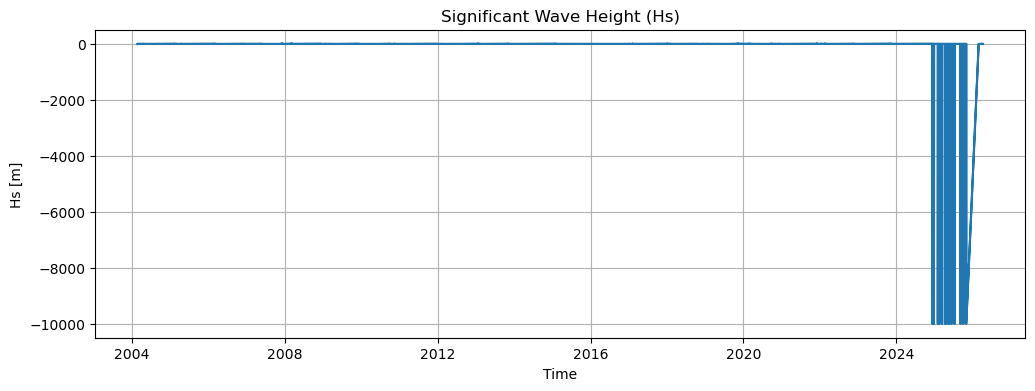

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";")

# Preview
df.head()
print(df.columns.tolist())
# Convert date
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y %m %d %H", errors="coerce")
df["Hs"] = pd.to_numeric(df["Hs"], errors="coerce")
# Set index
df.set_index("Fecha", inplace=True)
plt.figure(figsize=(12,4))
plt.plot(df["Hs"])
plt.title("Significant Wave Height (Hs)")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.grid()
plt.show()

## Data Quality Issues

When working with real coastal datasets, data quality problems are very common.

In this dataset, we observe:

- Presence of extreme values such as **-9999**
- These values do not represent physical measurements
- They are used as **missing data flags (NaN equivalents)**

### Why is this a problem?

- These values distort visualization
- They can completely break machine learning models
- They must be removed or properly handled before analysis

### Cleaning step

We replace invalid values (-9999) with NaN and remove them from the analysis.

After cleaning:
- The time series becomes physically meaningful
- However, **temporal gaps appear in the data**

These gaps are exactly the type of problem we aim to solve using Deep Learning methods such as LSTM.

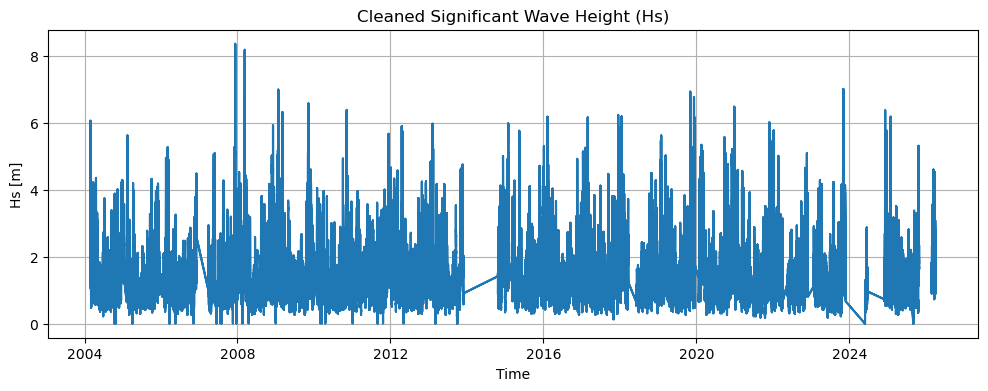

In [2]:
# Replace invalid values (-9999) with NaN
df["Hs"] = df["Hs"].replace(-9999.9, np.nan)

# Remove NaNs
df["Hs_clean"] = df["Hs"].replace(-9999.9, np.nan)

plt.figure(figsize=(12,4))
plt.plot(df["Hs"])
plt.title("Cleaned Significant Wave Height (Hs)")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.grid()
plt.show()

## Exploratory Data Analysis (EDA)

Before applying any machine learning model, it is essential to understand the data.

In this section, we will:
- analyze the distribution of the variables
- explore temporal patterns
- identify anomalies and gaps
- understand the structure of the dataset

This step is critical in any real data science workflow.

In [3]:
df["Hs_clean"].describe()


count    309708.000000
mean          1.419349
std           0.832626
min           0.000000
25%           0.830000
50%           1.200000
75%           1.780000
max           8.370000
Name: Hs_clean, dtype: float64

What values do we have?

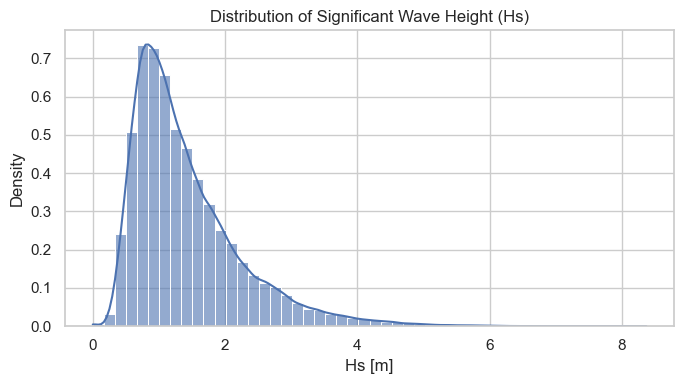

In [4]:
import seaborn as sns
# Set style
sns.set(style="whitegrid")

plt.figure(figsize=(7,4))

sns.histplot(
    df["Hs_clean"].dropna(),
    bins=50,
    kde=True,
    stat="density",
    alpha=0.6
)

plt.title("Distribution of Significant Wave Height (Hs)", fontsize=12)
plt.xlabel("Hs [m]")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

## Temporal Analysis

The distribution of wave height is useful, but it does not show how the system evolves in time.

In coastal engineering, temporal structure is essential:
- storms appear as peaks
- calm periods alternate with energetic conditions
- missing data may occur in blocks rather than randomly

For this reason, we now inspect the time series in detail.

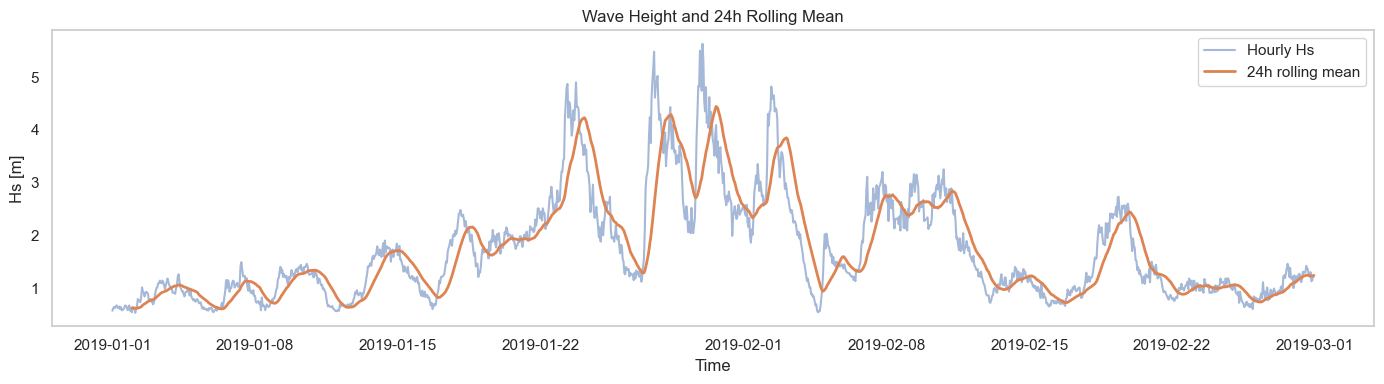

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";", low_memory=False)

# Clean likely junk
df.columns = df.columns.str.strip()
df["Fecha"] = df["Fecha"].astype(str).str.strip()
df["Hs"] = df["Hs"].astype(str).str.strip()

df = df[
    (df["Fecha"] != "Fecha") &
    (df["Fecha"] != "=======") &
    (df["Hs"] != "Hs")
].copy()

# Parse types
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y %m %d %H", errors="coerce")
df["Hs_clean"] = pd.to_numeric(df["Hs"], errors="coerce")

# Drop invalid rows
df = df.dropna(subset=["Fecha", "Hs_clean"]).copy()

# Set index and sort
df = df.set_index("Fecha").sort_index()

# Optional: remove duplicate timestamps
df = df[~df.index.duplicated(keep="first")]

# Zoom
df_zoom = df.loc["2019-01":"2019-02", ["Hs_clean"]].copy()
df_zoom["Hs_rolling"] = df_zoom["Hs_clean"].rolling(window=24).mean()

# Plot
plt.figure(figsize=(14, 4))
plt.plot(df_zoom.index, df_zoom["Hs_clean"], label="Hourly Hs", alpha=0.5)
plt.plot(df_zoom.index, df_zoom["Hs_rolling"], label="24h rolling mean", linewidth=2)

plt.title("Wave Height and 24h Rolling Mean")
plt.xlabel("Time")
plt.ylabel("Hs [m]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [6]:
n_total = df["Hs_clean"].shape[0]
n_missing = df["Hs_clean"].isna().sum()
missing_pct = 100 * n_missing / n_total

print(f"Total samples: {n_total}")
print(f"Missing samples: {n_missing}")
print(f"Missing percentage: {missing_pct:.2f}%")

Total samples: 154875
Missing samples: 0
Missing percentage: 0.00%


Not all gaps are the same. Some are short and others are very long. This greatly influences the difficulty of the problem.

## Problem Formulation

From the exploratory analysis, we observe that:

- the wave record has a clear temporal structure
- missing values are present and may occur in contiguous blocks
- the reconstruction problem is therefore not trivial

A suitable model should:
- exploit temporal dependence
- learn from previous observations
- reconstruct missing values in a physically consistent way

This motivates the use of recurrent neural networks, and in particular, LSTM models.

> Given a signal with a missing segment, estimate the missing values using temporal information from the surrounding data.

### Why is this challenging?
This is not a simple interpolation task because:
- the signal is nonlinear
- there may be energetic events and rapid changes
- temporal dependence is important

This motivates the use of sequence models such as **LSTM**.

## Train, Validation and Test Strategy

In this reconstruction problem, the artificially removed segment is used as the **test set**.

We define:

- **Training set**: temporal sequences before the gap
- **Validation set**: temporal sequences after the gap
- **Test set**: the missing segment itself

This strategy avoids mixing the target reconstruction interval with the data used for model fitting.

In [33]:
series = df_zoom["Hs_clean"].copy()

print("Total length:", len(series))
series.head()
# Temporal split
n = len(series)

train_end = int(n * 0.85)
val_end = int(n * 0.97)

train_series = series.iloc[:train_end].copy()
val_series = series.iloc[train_end:val_end].copy()
test_series = series.iloc[val_end:].copy()

print("Train length:", len(train_series))
print("Validation length:", len(val_series))
print("Test length:", len(test_series))

# Entire test period treated as missing
test_series_gap = test_series.copy()
test_series_gap[:] = np.nan

Total length: 1409
Train length: 1197
Validation length: 169
Test length: 43


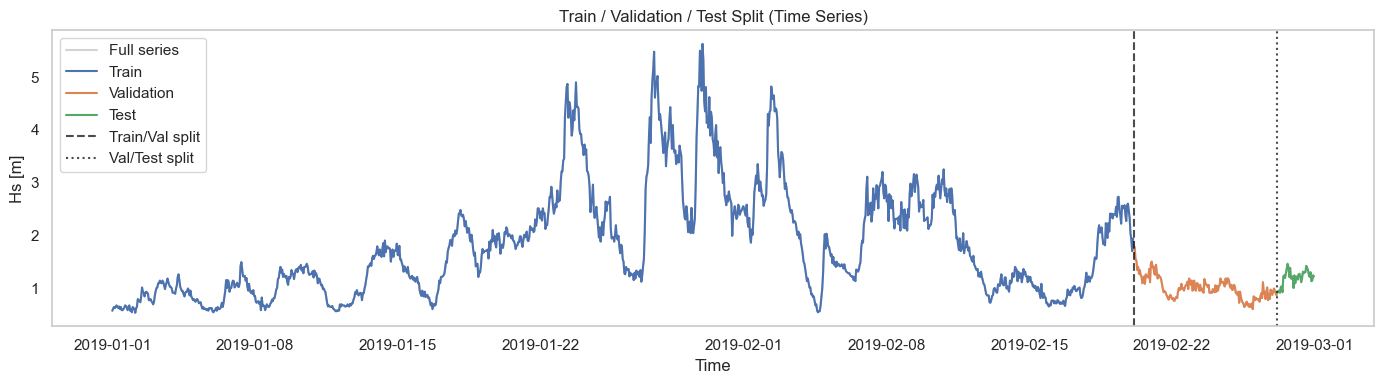

In [67]:
plt.figure(figsize=(14,4))

# Serie completa
plt.plot(series.index, series.values, color="lightgray", label="Full series")

# Splits
plt.plot(train_series.index, train_series.values, label="Train")
plt.plot(val_series.index, val_series.values, label="Validation")
plt.plot(test_series.index, test_series.values, label="Test")

# Líneas verticales de separación (MUY didáctico)
plt.axvline(val_series.index[0], color="black", linestyle="--", alpha=0.7, label="Train/Val split")
plt.axvline(test_series.index[0], color="black", linestyle=":", alpha=0.7, label="Val/Test split")

plt.title("Train / Validation / Test Split (Time Series)")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### GAP Reconstruction using LSTM

In this section, we simulate a real-world coastal engineering problem: missing data in time series. We artificially remove a segment of the wave height signal and use a Long Short-Term Memory (LSTM) neural network to reconstruct it.

The LSTM model learns temporal dependencies from the available data and predicts missing values based on past observations

In [51]:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1))
val_scaled = scaler.transform(val_series.values.reshape(-1, 1))
test_scaled = scaler.transform(test_series.values.reshape(-1, 1))

In [53]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 24

X_train, y_train = create_sequences(train_scaled, window_size)
X_val, y_val = create_sequences(val_scaled, window_size)
X_test, y_test = create_sequences(test_scaled, window_size)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1173, 24, 1)
y_train shape: (1173, 1)
X_val shape: (145, 24, 1)
y_val shape: (145, 1)
X_test shape: (19, 24, 1)
y_test shape: (19, 1)


In [54]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

C:\Users\user\anaconda3\envs\coastal-ml-seminar\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 24, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.3722 - val_loss: 0.0186
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1317 - val_loss: 0.0217
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0880 - val_loss: 0.0130
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0720 - val_loss: 0.0081
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0637 - val_loss: 0.0071
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0593 - val_loss: 0.0064
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0529 - val_loss: 0.0104
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0510 - val_loss: 0.0147
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0481 - val_loss: 0.0071
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0429 - val_loss: 0.0064
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0418 - val_loss: 0.0100
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0436 - val_l

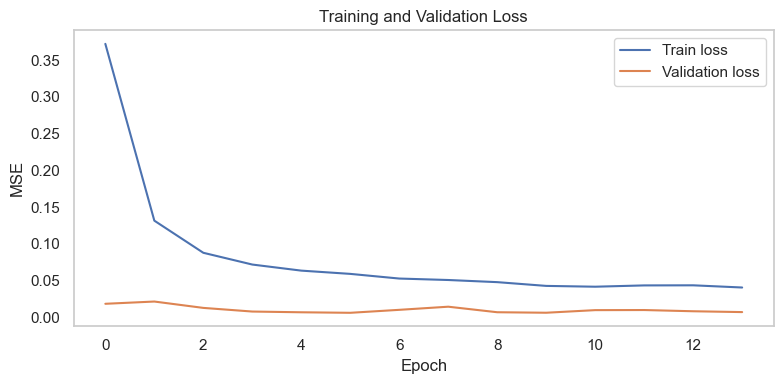

In [56]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [57]:
y_val_pred_scaled = model.predict(X_val, verbose=0)

In [58]:
y_val_naive_scaled = X_val[:, -1, 0].reshape(-1, 1)

In [59]:
y_val_true = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_val_pred = scaler.inverse_transform(y_val_pred_scaled).flatten()
y_val_naive = scaler.inverse_transform(y_val_naive_scaled).flatten()

## Model Evaluation

To assess the performance of the LSTM model in reconstructing the missing segment, we use several standard evaluation metrics:

### Root Mean Squared Error (RMSE)

Measures the average magnitude of the error:

$$
RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}
$$

---

### Coefficient of Determination ($R^2$)

Indicates how well predictions match observations:

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

---

### Mean Absolute Percentage Error (MAPE)

Measures relative error:

$$
MAPE = \frac{100}{N} \sum \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

---

### Bias

Indicates systematic over/underestimation:

$$
Bias = \frac{1}{N} \sum (\hat{y}_i - y_i)
$$

---

These metrics are computed **only on the artificially removed gap**, which simulates missing data reconstruction.


In [64]:
rmse_lstm = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
mae_lstm = mean_absolute_error(y_val_true, y_val_pred)

rmse_naive = np.sqrt(mean_squared_error(y_val_true, y_val_naive))
mae_naive = mean_absolute_error(y_val_true, y_val_naive)

print("Validation metrics")
print(f"LSTM  -> RMSE: {rmse_lstm:.4f} | MAE: {mae_lstm:.4f}")
print(f"Naive -> RMSE: {rmse_naive:.4f} | MAE: {mae_naive:.4f}")

Validation metrics
LSTM  -> RMSE: 0.0827 | MAE: 0.0662
Naive -> RMSE: 0.0929 | MAE: 0.0721


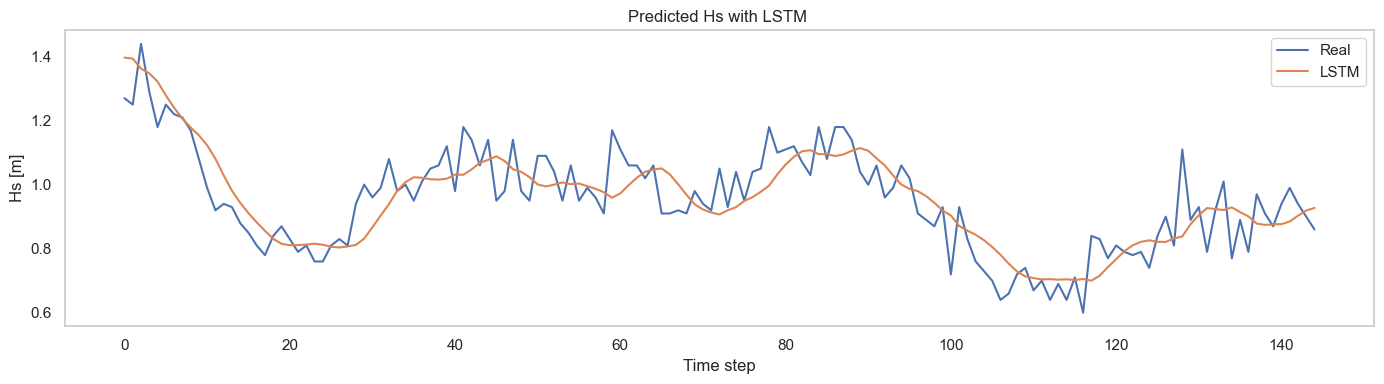

In [66]:
n_plot = 200

plt.figure(figsize=(14,4))
plt.plot(y_val_true[:n_plot], label="Real")

plt.plot(y_val_pred[:n_plot], label="LSTM")
plt.title("Predicted Hs with LSTM ")
plt.xlabel("Time step")
plt.ylabel("Hs [m]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [72]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# --- Métricas ---
rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
r2 = r2_score(y_val_true, y_val_pred)

# Evitar división por cero en MAPE
epsilon = 1e-8
mape = np.mean(np.abs((y_val_true - y_val_pred) / (y_val_true + epsilon))) * 100

bias = np.mean(y_val_pred - y_val_true)

# --- Crear tabla ---
metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "R²", "MAPE (%)", "Bias"],
    "Value": [rmse, r2, mape, bias]
})

# Redondear para presentación
metrics_df["Value"] = metrics_df["Value"].round(4)

# Mostrar tabla

metrics_df.style.set_caption("Model Evaluation Metrics (Validation Set)") \
    .format({"Value": "{:.4f}"})

,Metric,Value
0,RMSE,0.0827
1,R²,0.7174
2,MAPE (%),7.0479
3,Bias,0.0029
